In [31]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from tqdm.auto import tqdm
import numpy as np
from PIL import Image
import random
from torchvision import transforms
from PIL import Image as PILImage
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

project_path = 'C:\\Users\\Salvatore\\anaconda3\\envs\\torch_shap_cuda\\src\\MasterAI\\progetto-finale-flowes\\progetto-finale-flowes'
os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

print(f"Current working directory changed to: {os.getcwd()}")

Current working directory changed to: C:\Users\Salvatore\anaconda3\envs\torch_shap_cuda\src\MasterAI\progetto-finale-flowes\progetto-finale-flowes


In [32]:
train_path = os.path.join(os.getcwd(), 'train')

print(f"Contents of the training directory '{train_path}':")
if os.path.exists(train_path):
    for item in os.listdir(train_path):
        item_path = os.path.join(train_path, item)
        if os.path.isdir(item_path):
            num_files = len([f for f in os.listdir(item_path) if os.path.isfile(os.path.join(item_path, f))])
            print(f"- {item}/ (Contains {num_files} files)")
        else:
            print(f"- {item}")
else:
    print(f"Error: Training directory '{train_path}' not found.")


Contents of the training directory 'C:\Users\Salvatore\anaconda3\envs\torch_shap_cuda\src\MasterAI\progetto-finale-flowes\progetto-finale-flowes\train':
- .DS_Store
- ._.DS_Store
- ._daisy
- ._dandelion
- daisy/ (Contains 1058 files)
- dandelion/ (Contains 1492 files)



Displaying sample images from 'daisy' class in the training set:


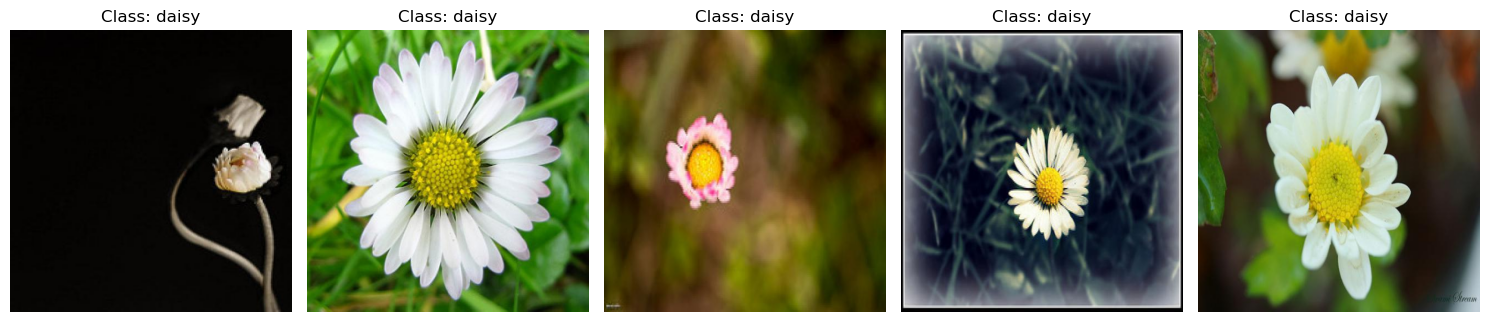


Displaying sample images from 'dandelion' class in the training set:


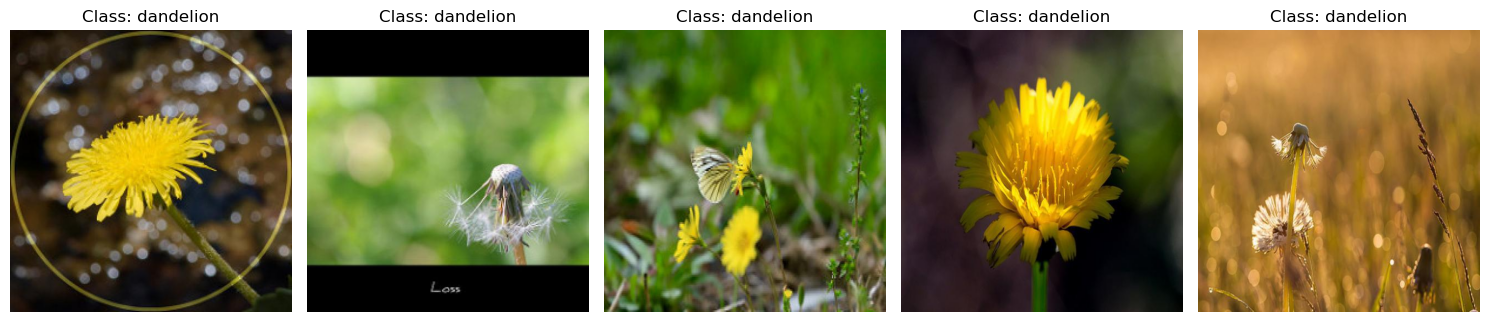

In [ ]:
# Define the class names to display
class_names_to_display = ['daisy', 'dandelion']

for class_name in class_names_to_display:
    class_path = os.path.join(train_path, class_name)

    if os.path.exists(class_path):
        print(f"\nDisplaying sample images from '{class_name}' class in the training set:")

        # Get all image files in the class directory, filtering out macOS metadata files (e.g., ._*)
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')) and not f.startswith('._')]

        if image_files:
            # Select a few random images (e.g., 5 images)
            sample_images = random.sample(image_files, min(5, len(image_files)))

            plt.figure(figsize=(15, 5))
            for i, img_name in enumerate(sample_images):
                img_path = os.path.join(class_path, img_name)
                img = mpimg.imread(img_path)

                plt.subplot(1, min(5, len(sample_images)), i + 1)
                plt.imshow(img)
                plt.title(f"Class: {class_name}")
                plt.axis('off')
            plt.tight_layout()
            plt.show()
        else:
            print(f"No valid image files found in '{class_path}'.")
    else:
        print(f"Error: Class directory '{class_path}' not found.")

Dataset Distribution Summary:
----------------------------

Train Split:
- Daisy: 529 images
- Dandelion: 746 images
  Total images in train: 1275

Validation Split:
- Daisy: 163 images
- Dandelion: 201 images
  Total images in validation: 364

Test Split:
- Daisy: 77 images
- Dandelion: 105 images
  Total images in test: 182

Detailed Data Summary (DataFrame):


,Split,Class,Count
0,train,daisy,529
1,train,dandelion,746
2,validation,daisy,163
3,validation,dandelion,201
4,test,daisy,77
5,test,dandelion,105



Overall Class Balance (Training, Validation, Test combined):


,Class,Count
0,daisy,769
1,dandelion,1052


<Figure size 1000x500 with 0 Axes>

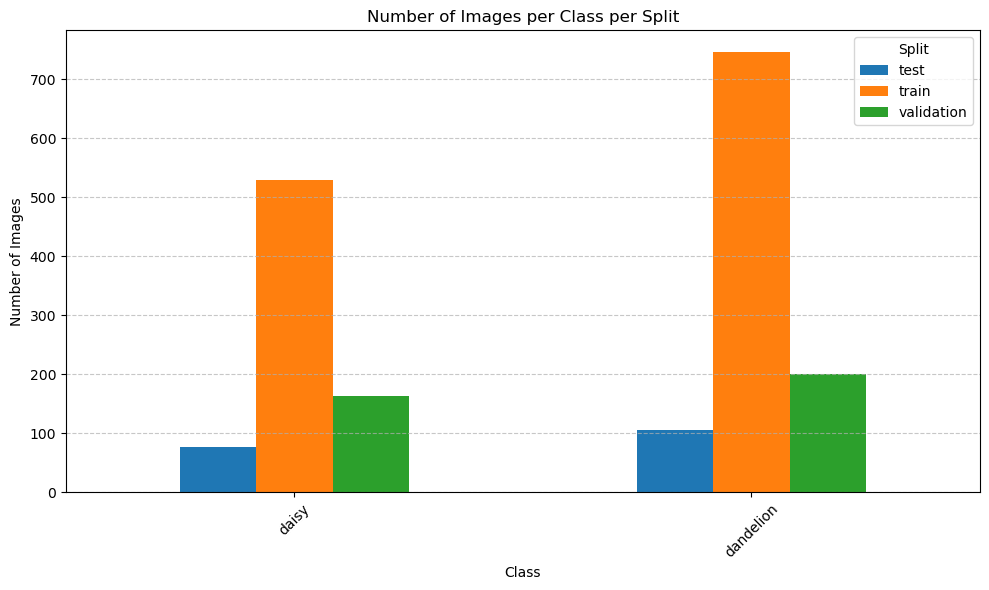

<Figure size 700x700 with 0 Axes>

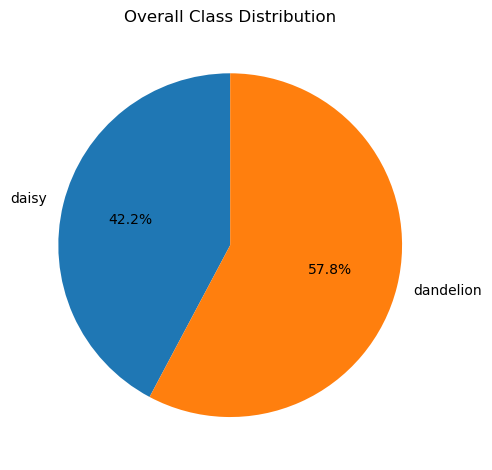

In [ ]:
# Define base paths for the splits
base_path = os.getcwd()
train_path = os.path.join(base_path, 'train')
val_path = os.path.join(base_path, 'valid') # Assuming 'val' is the validation folder
test_path = os.path.join(base_path, 'test') # Assuming 'test' is the test folder

splits = {'train': train_path, 'validation': val_path, 'test': test_path}
class_names = ['daisy', 'dandelion']

data_summary = []

print("Dataset Distribution Summary:")
print("----------------------------")

for split_name, path in splits.items():
    if not os.path.exists(path):
        print(f"Warning: {split_name.capitalize()} directory '{path}' not found. Skipping.\n")
        continue

    print(f"\n{split_name.capitalize()} Split:")
    total_images_in_split = 0
    for class_name in class_names:
        class_dir = os.path.join(path, class_name)
        if os.path.exists(class_dir):
            # Count valid image files, ignoring macOS metadata files
            image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')) and not f.startswith('._')]
            num_images = len(image_files)
            print(f"- {class_name.capitalize()}: {num_images} images")
            data_summary.append({'Split': split_name, 'Class': class_name, 'Count': num_images})
            total_images_in_split += num_images
        else:
            print(f"- Warning: Class directory '{class_name}' not found in {split_name} split.")
    print(f"  Total images in {split_name}: {total_images_in_split}")

# Display as a DataFrame for better readability
df_summary = pd.DataFrame(data_summary)
if not df_summary.empty:
    print("\nDetailed Data Summary (DataFrame):")
    display(df_summary)

    # Check overall balance
    print("\nOverall Class Balance (Training, Validation, Test combined):")
    overall_balance = df_summary.groupby('Class')['Count'].sum().reset_index()
    display(overall_balance)

    # Optionally, visualize the balance
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    df_summary.pivot_table(index='Class', columns='Split', values='Count').plot(kind='bar', figsize=(10, 6))
    plt.title('Number of Images per Class per Split')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Overall class balance plot
    plt.figure(figsize=(7, 7))
    overall_balance.set_index('Class').plot(kind='pie', y='Count', autopct='%1.1f%%', startangle=90, legend=False)
    plt.title('Overall Class Distribution')
    plt.ylabel('') # Hide the default 'Count' label on y-axis for pie chart
    plt.tight_layout()
    plt.show()
else:
    print("No data found for summary generation.")

## Analisi del Bilanciamento del Dataset

Il dataset presenta una **distribuzione moderatamente sbilanciata**: la classe *dandelion* conta circa il 58% delle immagini overall rispetto al 42% di *daisy*. Non siamo di fronte a uno sbilanciamento critico che richiederebbe interventi immediati. Tuttavia, non voglio trascurarlo ed implemento:
- **Class weighting** nel parametro `weight` di `CrossEntropyLoss`, proporzionale all'inverso della frequenza nel set di train.

In [35]:
# --- HYPERPARAMETERS ---
BATCH_SIZE = 32
EPOCHS_PHASE1 = 10   # head-only training
EPOCHS_PHASE2 = 15   # full backbone fine-tuning
LR_PHASE1 = 1e-3
LR_PHASE2 = 5e-5
PATIENCE = 5
NUM_WORKERS = 0
IMG_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


# Vediamo bene cosa sto dando in pasto alla rete

Classi: ['daisy', 'dandelion']  |  Train: 1275  |  Val: 364


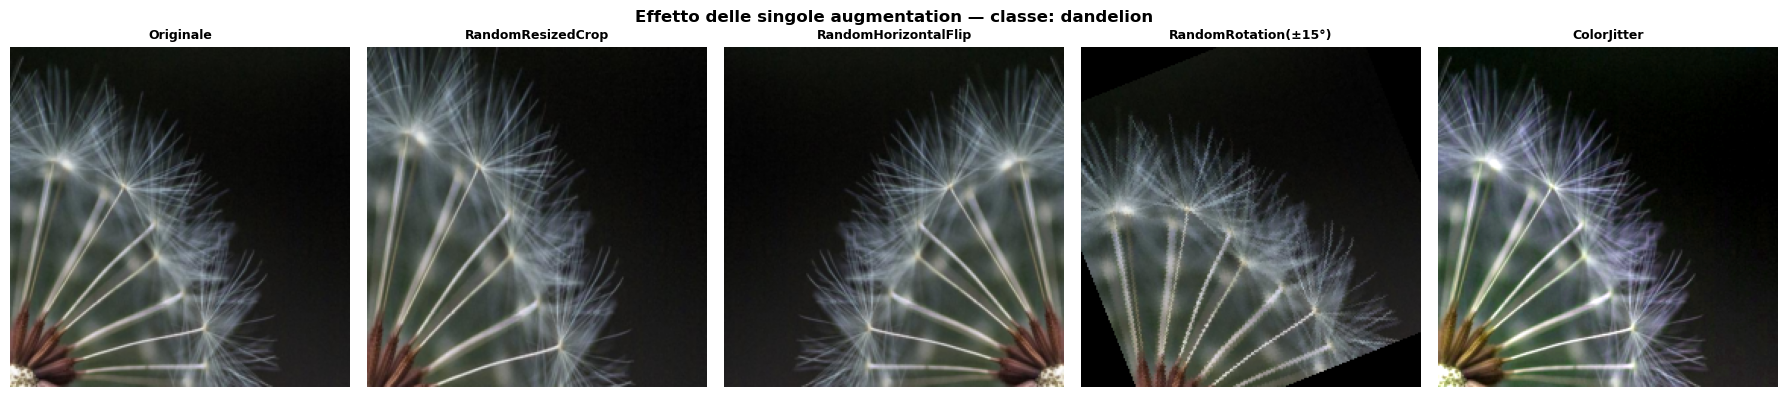

In [36]:
# --- CUSTOM LOADER (filtra metadati macOS) ---
def is_valid_image(path):
    filename = os.path.basename(path)
    return not filename.startswith('._') and filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))

# --- DATA AUGMENTATION ---
# Val/test: solo resize + normalize (no augmentation: valutazione deterministica)
# Train: augmentation ricca per migliorare la generalizzazione
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 0.8)),   # zoom variabile + crop
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),                               # rotazione ±30°
        transforms.ColorJitter(brightness=0.3, contrast=0.3,        # variazioni colore
                               saturation=0.3, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

train_dataset = datasets.ImageFolder(
    os.path.join(os.getcwd(), 'train'), data_transforms['train'], is_valid_file=is_valid_image)
val_dataset = datasets.ImageFolder(
    os.path.join(os.getcwd(), 'valid'), data_transforms['valid'], is_valid_file=is_valid_image)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

num_classes = len(train_dataset.classes)
CLASS_NAMES = train_dataset.classes
print(f"Classi: {CLASS_NAMES}  |  Train: {len(train_dataset)}  |  Val: {len(val_dataset)}")


# Prendi un'immagine campione dal training set
sample_path, sample_label = train_dataset.imgs[random.randint(0, len(train_dataset.imgs)-8)]
orig = PILImage.open(sample_path).convert('RGB')

# Una trasformazione per volta (senza normalize per visualizzare)
augmentations = {
    'Originale':             transforms.Resize((IMG_SIZE, IMG_SIZE)),
    'RandomResizedCrop':     transforms.Compose([transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 0.8))]),
    'RandomHorizontalFlip':  transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomHorizontalFlip(p=1.0)]),
    'RandomRotation(±15°)':  transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomRotation(30)]),
    'ColorJitter':           transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)]),
}

fig, axes = plt.subplots(1, len(augmentations), figsize=(18, 4))
for ax, (name, tfm) in zip(axes, augmentations.items()):
    ax.imshow(tfm(orig))
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Effetto delle singole augmentation — classe: {CLASS_NAMES[sample_label]}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

c:\Users\Salvatore\anaconda3\envs\torch_shap_cuda\lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Salvatore\.cache\huggingface\hub\models--timm--resnet50.a1_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)



Parametri totali: 23,512,130

FASE 1: Training della classifier head (backbone congelato)
Parametri trainable (Fase 1): 4,098


[Fase 1] Epoch 1/10 [Train]:   0%|          | 0/40 [00:00<?, ?it/s]

[Fase 1] Epoch 1/10 [Val]:   0%|          | 0/12 [00:00<?, ?it/s]

...

[Fase 2] Epoch 14/15 [Val]:   0%|          | 0/12 [00:00<?, ?it/s]

[Fase 2] Epoch 14/15 | LR: 5.46e-07 | Train Loss: 0.1232  Acc: 0.9553 | Val Loss: 0.1430  Acc: 0.9423


[Fase 2] Epoch 15/15 [Train]:   0%|          | 0/40 [00:00<?, ?it/s]

[Fase 2] Epoch 15/15 [Val]:   0%|          | 0/12 [00:00<?, ?it/s]

[Fase 2] Epoch 15/15 | LR: 0.00e+00 | Train Loss: 0.1119  Acc: 0.9616 | Val Loss: 0.1511  Acc: 0.9341


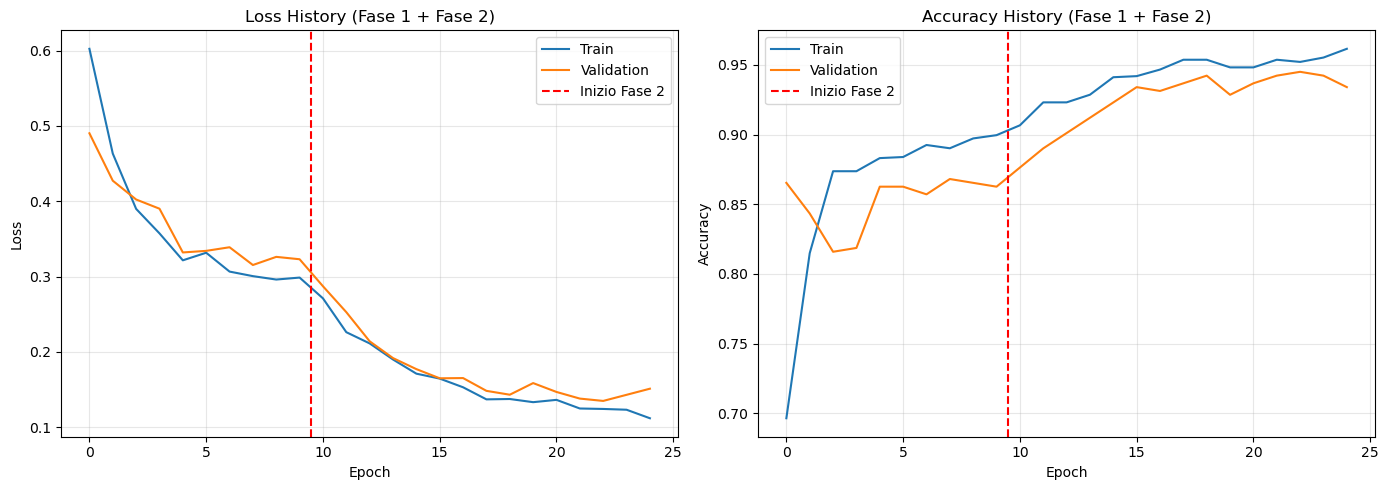

In [37]:
# --- TRAINING HELPERS ---
def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE, desc=""):
    """Esegue un'epoca di training o validation. Se optimizer=None → modalità eval."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    running_loss, running_corrects = 0.0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        pbar = tqdm(loader, desc=desc, leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            if is_train:
                optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            _, preds = torch.max(outputs, 1)
            running_loss     += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = running_corrects.double() / len(loader.dataset)
    return epoch_loss, epoch_acc.item()


def train_phase(model, train_loader, val_loader, criterion, optimizer, scheduler,
                epochs, patience, save_path, phase_name):
    """Loop completo con early stopping e salvataggio del best model."""
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    counter = 0

    for epoch in range(epochs):
        train_loss, train_acc = run_epoch(
            model, train_loader, criterion, optimizer,
            desc=f"[{phase_name}] Epoch {epoch+1}/{epochs} [Train]")
        val_loss, val_acc = run_epoch(
            model, val_loader, criterion,
            desc=f"[{phase_name}] Epoch {epoch+1}/{epochs} [Val]")

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"[{phase_name}] Epoch {epoch+1:02d}/{epochs} | LR: {current_lr:.2e} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Best model salvato (val_loss={best_val_loss:.4f})")
        else:
            counter += 1
            if counter >= patience:
                print(f"  Early stopping all'epoca {epoch+1}")
                break

    return history


# --- MODEL ---
model = timm.create_model('resnet50', pretrained=True, num_classes=num_classes)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
print(f"\nParametri totali: {total_params:,}")


# =====================================================================
# FASE 1: Addestramento solo della classifier head
# =====================================================================
print("\n" + "="*65)
print("FASE 1: Training della classifier head (backbone congelato)")
print("="*65)

for param in model.parameters():
    param.requires_grad = False
for param in model.get_classifier().parameters():
    param.requires_grad = True

trainable_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametri trainable (Fase 1): {trainable_p1:,}")

optimizer_p1 = optim.Adam(model.get_classifier().parameters(), lr=LR_PHASE1)
scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=EPOCHS_PHASE1)

# Calcola pesi inversamente proporzionali alla frequenza delle classi
class_counts = torch.tensor(
    [train_dataset.targets.count(i) for i in range(num_classes)],
    dtype=torch.float
) #anche se il numero delle classi è 2, è buona pratica generalizzare
class_weights = (1.0 / class_counts)
class_weights = class_weights / class_weights.sum()   # normalizza
class_weights = class_weights.to(DEVICE)

criterion_p1 = nn.CrossEntropyLoss(weight=class_weights)

history_p1 = train_phase(
    model, train_loader, val_loader, criterion_p1,
    optimizer_p1, scheduler_p1,
    EPOCHS_PHASE1, PATIENCE, 'best_model_phase1.pth', "Fase 1")


# =====================================================================
# FASE 2: Full fine-tuning (backbone + head, LR molto basso)
# =====================================================================
print("\n" + "="*65)
print("FASE 2: Full fine-tuning (backbone sbloccato, LR ridotto)")
print("="*65)

model.load_state_dict(torch.load('best_model_phase1.pth'))

for param in model.parameters():
    param.requires_grad = True

trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametri trainable (Fase 2): {trainable_p2:,}")

optimizer_p2 = optim.Adam(model.parameters(), lr=LR_PHASE2)
scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=EPOCHS_PHASE2)

# Calcola pesi inversamente proporzionali alla frequenza delle classi
class_counts = torch.tensor(
    [train_dataset.targets.count(i) for i in range(num_classes)],
    dtype=torch.float
)
class_weights = (1.0 / class_counts)
class_weights = class_weights / class_weights.sum()   # normalizza
class_weights = class_weights.to(DEVICE)

criterion_p2 = nn.CrossEntropyLoss(weight=class_weights)

history_p2 = train_phase(
    model, train_loader, val_loader, criterion_p2,
    optimizer_p2, scheduler_p2,
    EPOCHS_PHASE2, PATIENCE, 'best_model.pth', "Fase 2")


# --- GRAFICO HISTORY COMBINATO ---
def plot_combined_history(h1, h2):
    p2_start = len(h1['train_loss'])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, ylabel in zip(axes,
            [('train_loss', 'val_loss'), ('train_acc', 'val_acc')],
            ['Loss', 'Accuracy']):
        train_data = h1[metric[0]] + h2[metric[0]]
        val_data   = h1[metric[1]] + h2[metric[1]]
        ax.plot(train_data, label='Train')
        ax.plot(val_data,   label='Validation')
        ax.axvline(p2_start - 0.5, color='red', linestyle='--', linewidth=1.5, label='Inizio Fase 2')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel} History (Fase 1 + Fase 2)')
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_combined_history(history_p1, history_p2)

## Analisi del Training

Il **fine-tuning progressivo** proposto nella revisione è stato implementato come:

- **Fase 1 — Head only** (`LR = 1e-3`): congela il backbone e addestra solo il classificatore lineare finale.

- **Fase 2 — Full fine-tuning** (`LR = 5e-5`): sblocca l'intero backbone e continua il training con un LR molto basso. In questa fase il modello adatta sottilmente le rappresentazioni intermedie al dominio specifico (texture dei petali, morfologia dei fiori).

Inoltre come consigliato è stato implementato uno scheduler, il **CosineAnnealingLR** che scala il learning rate in entrambe le fasi. La linea tratteggiata rossa nel grafico segna il confine tra le due fasi. 

Per aumentare ulteriormente le performance ho sostituito la mia backbone con una resnet50. Dai grafici e dalle performance si può notare un miglioramento di circa il 3-4% in accuracy su train e val rispetto al codice precedente

# Visualizzazione delle metriche rilevanti sul set di test

Testing:   0%|          | 0/6 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

       daisy       0.89      0.96      0.93        77
   dandelion       0.97      0.91      0.94       105

    accuracy                           0.93       182
   macro avg       0.93      0.94      0.93       182
weighted avg       0.94      0.93      0.93       182

Macro F1-Score sul Test Set: 0.9331


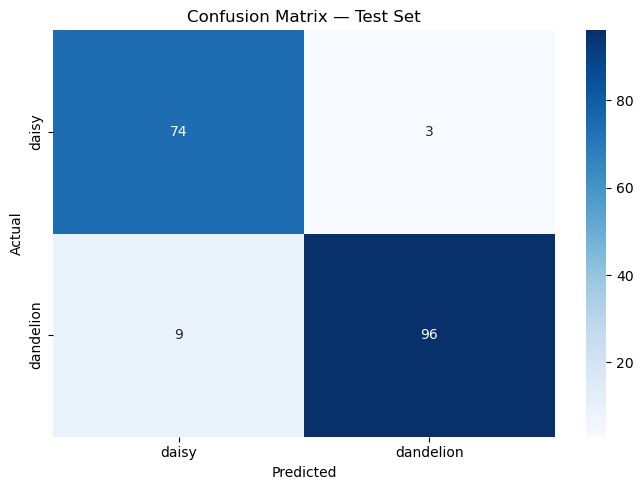

In [38]:
# --- TEST DATA ---
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(
    os.path.join(os.getcwd(), 'test'), test_transforms, is_valid_file=is_valid_image)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
class_names = test_dataset.classes

# --- LOAD BEST MODEL (Phase 2) ---
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []   # probabilità softmax per ogni campione → usate nell'analisi successiva

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        probs   = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)   # shape: [N, num_classes]

# --- METRICS ---
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

macro_f1 = f1_score(all_labels, all_preds, average='macro')
print(f"Macro F1-Score sul Test Set: {macro_f1:.4f}")

# --- CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

## Analisi delle Metriche sul Test Set

Il modello sbaglia **12 immagini su 182** (error rate ~6.6%).

**Daisy** (recall=0.96 > precision=0.89): il modello identifica quasi tutte le margherite reali (solo 3 mancate su 77), ma classifica 9 dandelion come daisy. L'alta recall con precision leggermente più bassa indica che il decision boundary è conservativo verso daisy: il modello preferisce "sbagliare per eccesso" su questa classe piuttosto che perderla.

**Dandelion** (precision=0.97 > recall=0.91): quando il modello predice "dandelion" ha quasi sempre ragione (solo 3 falsi positivi), ma manca 9 dandelion reali. L'alta precision riflette la maggiore rappresentazione di questa classe nel training set.

**Conclusione sullo sbilanciamento**: nonostante il leggero sbilanciamento, i due recall sono entrambi elevati e relativamente bilanciati (0.96 vs 0.91). Il fine-tuning progressivo con augmentation e il class weighting hanno incrementato le performance (rispetto alla precedente submission) ed efficacemente contrastato il potenziale bias verso la classe maggioritaria.


## Analisi degli Errori

Visualizzare le immagini mal classificate dopo il training mi porta a 2 casistiche da analizzare:

- **Errori con bassa confidence** → il modello è incerto, probabilmente immagini ambigue o ai confini del decision boundary. Questi errori sono attesi e "comprensibili".
- **Errori con alta confidence** → il modello è sicuro ma sbaglia: sintomo di bias sistematico, overfitting su determinati pattern, o immagini molto atipiche della classe.

Campioni mal classificati: 12 / 182 (6.6%)



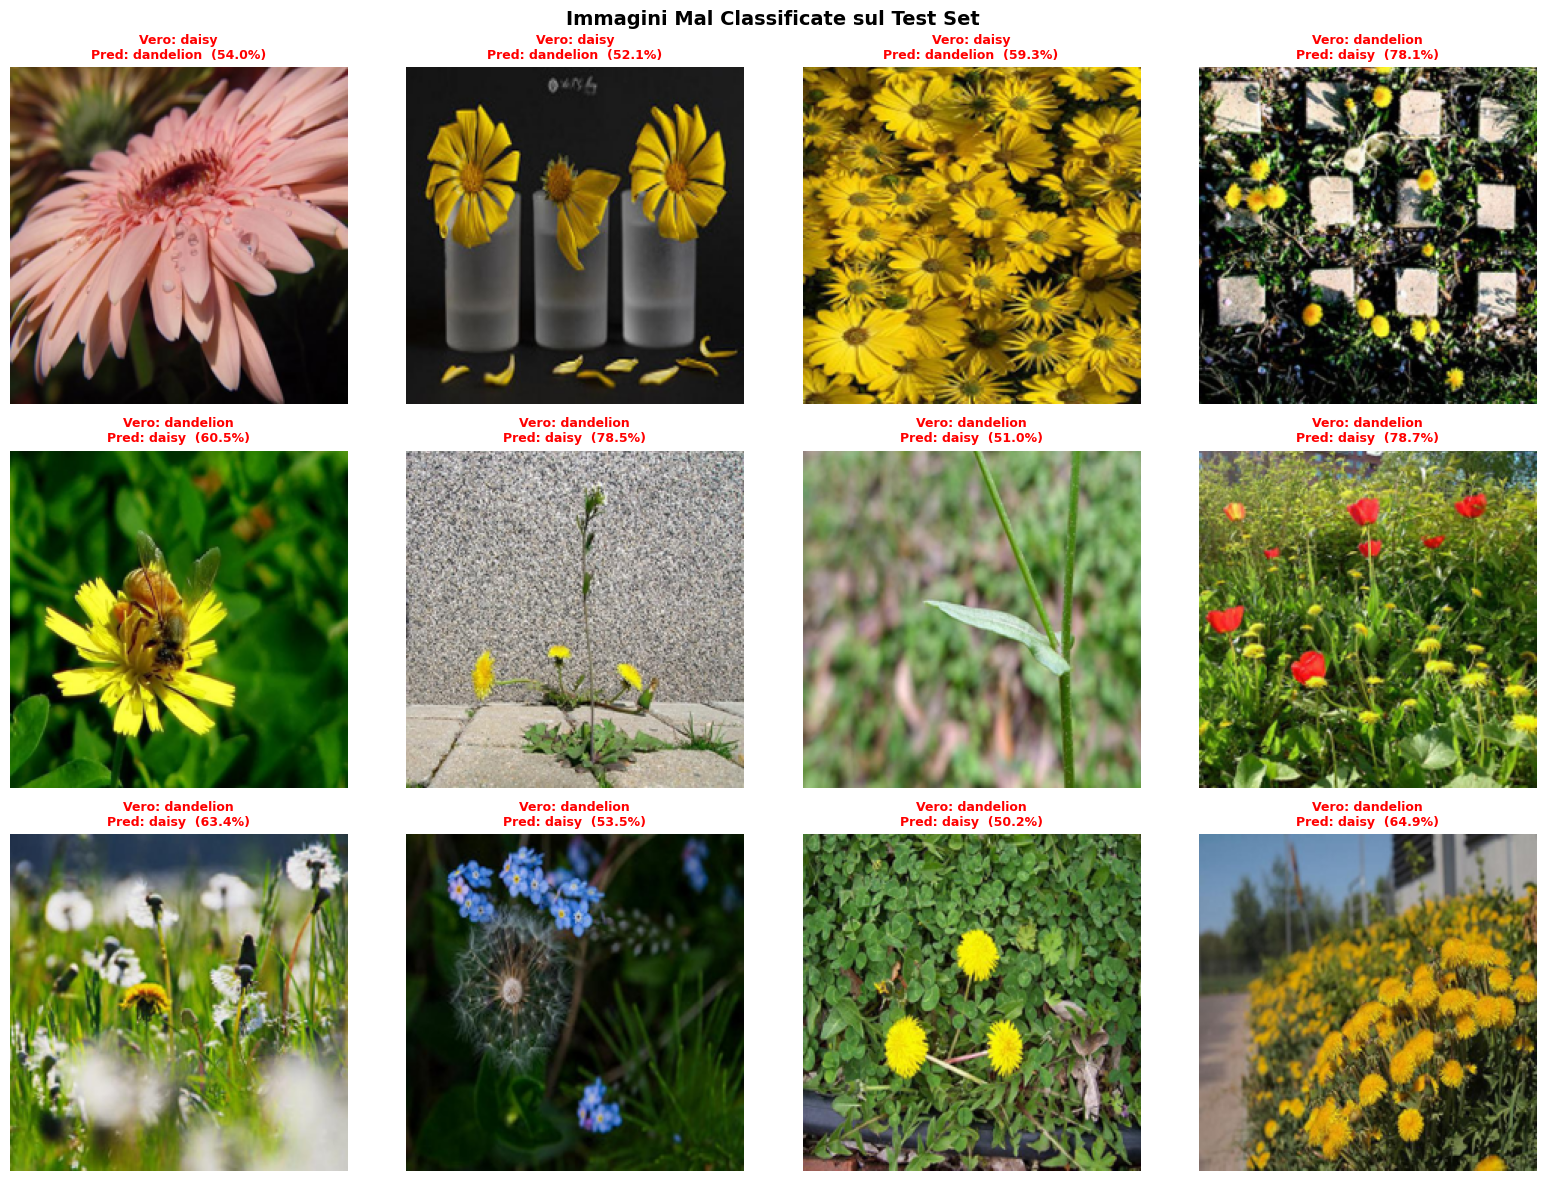

Errori per classe vera:
         daisy: 3/77 errati  (3.9%  error rate)
     dandelion: 9/105 errati  (8.6%  error rate)


In [39]:
# --- ANALISI DEGLI ERRORI: Visualizzazione delle immagini mal classificate ---

misclassified_indices = np.where(all_preds != all_labels)[0]
print(f"Campioni mal classificati: {len(misclassified_indices)} / {len(all_labels)} "
      f"({100 * len(misclassified_indices) / len(all_labels):.1f}%)\n")

n_show = min(12, len(misclassified_indices))
if n_show == 0:
    print("Nessun errore sul test set.")
else:
    cols = 4
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten()

    for i, idx in enumerate(misclassified_indices[:n_show]):
        img_path, _ = test_dataset.imgs[idx]
        img = PILImage.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

        true_lbl = class_names[all_labels[idx]]
        pred_lbl = class_names[all_preds[idx]]
        conf     = all_probs[idx][all_preds[idx]] * 100

        axes[i].imshow(img)
        axes[i].set_title(
            f"Vero: {true_lbl}\nPred: {pred_lbl}  ({conf:.1f}%)",
            color='red', fontsize=9, fontweight='bold')
        axes[i].axis('off')

    for j in range(n_show, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Immagini Mal Classificate sul Test Set', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Breakdown per classe: dove sbaglia di più?
    print("Errori per classe vera:")
    for cls_idx, cls_name in enumerate(class_names):
        cls_errors = np.sum((all_labels == cls_idx) & (all_preds != all_labels))
        cls_total  = np.sum(all_labels == cls_idx)
        print(f"  {cls_name:>12}: {cls_errors}/{cls_total} errati  "
              f"({100*cls_errors/cls_total:.1f}%  error rate)")

# Analisi immagini mal classificate
Su 12 errori solo 3 vanno oltre il 70% di confidenza (penso a causa della presenza degli evidenti pattern), quindi possiamo dire che in questi contesti la rete fa un po' di fatica. Tuttavia negli altri contesti (evidentemente poco chiari) sono contento che la rete mostri un comportamento non confidente nella predizione.

## Grad-CAM

Utilizzo un algoritmo XAI per capire dove la rete sta ponendo la sua attenzione durante i suoi processi decisionali. Questo algoritmo produce una mappa di calore:

- **Rosso/caldo** = regione ad alto peso per la decisione
- **Blu/freddo** = regione poco influente

**Mi aspetto** Heatmap concentrate sulle strutture botaniche  → il modello ha imparato feature semanticamente corrette

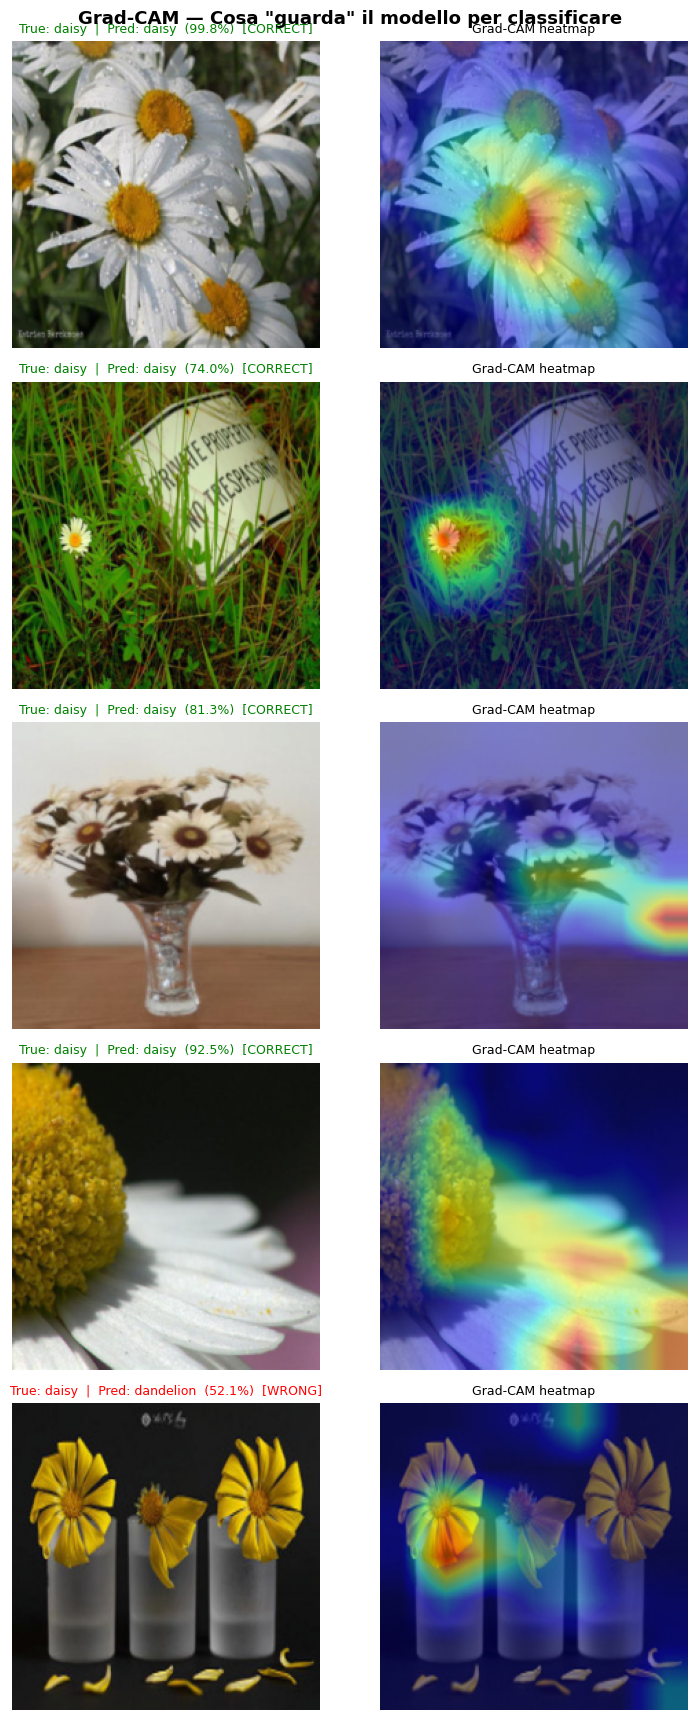

In [43]:
# --- GRAD-CAM VISUALIZATION ---
# Implementazione manuale: nessuna libreria esterna richiesta oltre a PyTorch

class GradCAM:
    """
    Gradient-weighted Class Activation Mapping (Grad-CAM).
    Genera una heatmap che evidenzia le regioni dell'immagine più rilevanti
    per la decisione del modello, usando i gradienti dell'ultimo blocco conv.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self._acts  = None
        self._grads = None

        def fwd_hook(m, inp, out):
            self._acts = out.detach()

        def bwd_hook(m, grad_in, grad_out):
            self._grads = grad_out[0].detach()

        self._fwd = target_layer.register_forward_hook(fwd_hook)
        self._bwd = target_layer.register_full_backward_hook(bwd_hook)

    def remove(self):
        self._fwd.remove()
        self._bwd.remove()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        out  = self.model(x)
        pred = out.argmax(dim=1).item() if class_idx is None else class_idx
        self.model.zero_grad()
        out[0, pred].backward()
        # Global average pooling sui gradienti → pesi per ciascun canale
        w   = self._grads[0].mean(dim=(1, 2))                      # [C]
        cam = torch.relu((w[:, None, None] * self._acts[0]).sum(dim=0))  # [H, W]
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.cpu().numpy(), pred


# Target: ultimo blocco residuale di ResNet-50
target_layer = model.layer4[-1]
grad_cam     = GradCAM(model, target_layer)

# Campiona: 4 corretti + fino a 4 sbagliati
correct_indices      = np.where(all_preds == all_labels)[0]
misclassified_indices_gc = misclassified_indices[:min(4, len(misclassified_indices))]
sample_indices = np.concatenate([
    np.random.choice(correct_indices, size=min(4, len(correct_indices)), replace=False),
    misclassified_indices_gc[1:2]
])

# Denormalizzazione per la visualizzazione
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

n = len(sample_indices)
fig, axes = plt.subplots(n, 2, figsize=(8, 3.5 * n))
if n == 1:
    axes = axes[np.newaxis, :]

for row, idx in enumerate(sample_indices):
    img_path, _ = test_dataset.imgs[idx]
    img_tensor  = test_transforms(PILImage.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    img_vis     = inv_normalize(img_tensor.squeeze().cpu()).permute(1, 2, 0).clamp(0, 1).numpy()

    cam, pred_idx = grad_cam(img_tensor)
    cam_up = np.array(PILImage.fromarray((cam * 255).astype(np.uint8))
                      .resize((IMG_SIZE, IMG_SIZE), PILImage.BILINEAR)) / 255.0

    true_lbl = class_names[all_labels[idx]]
    pred_lbl = class_names[pred_idx]
    status   = "CORRECT" if all_labels[idx] == pred_idx else "WRONG"
    color    = "green" if status == "CORRECT" else "red"
    conf     = all_probs[idx][pred_idx] * 100

    axes[row, 0].imshow(img_vis)
    axes[row, 0].set_title(
        f"True: {true_lbl}  |  Pred: {pred_lbl}  ({conf:.1f}%)  [{status}]",
        color=color, fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(img_vis)
    axes[row, 1].imshow(cam_up, cmap='jet', alpha=0.45)
    axes[row, 1].set_title("Grad-CAM heatmap", fontsize=9)
    axes[row, 1].axis('off')

grad_cam.remove()
plt.suptitle("Grad-CAM — Cosa \"guarda\" il modello per classificare", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Analisi con Grad-CAM
Come si può vedere dalla sovrapposizione con grad-CAM, nei casi in cui sta predicendo correttamente la rete sta focalizzando la sua attenzione sulla specie floreale (abbiamo più prove di ciò basta vedere le immagini classificate correttamente, nella seconda immagine in particolare riesce a focalizzarsi su un target molto piccolo!). 
Nel caso in cui classifica male, non focalizza molto bene sulla specie floreale e come si può notare in questa immagine c'è un pattern (che può avere influito).
Unica nota negativa che mi fa pensare al fatto che forse possono essere migliorate ulteriormente le performance è l'immagine 3 (a partire dalla superiore) che sta predicendo bene ma si sta focalizzando sulla parte sbagliata della rete (forse a causa di un minimo di overfitting)
